In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/wait_times.csv")
df.shape



(2604, 6)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2156 entries, 0 to 2155
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   port_name     2156 non-null   str    
 1   category      2156 non-null   str    
 2   lane_type     2156 non-null   str    
 3   status        2156 non-null   str    
 4   wait_minutes  1089 non-null   float64
 5   timestamp     2156 non-null   str    
dtypes: float64(1), str(5)
memory usage: 101.2 KB


In [10]:
df.head()


,port_name,category,lane_type,status,wait_minutes,timestamp
0,Bridge of the Americas,Commercial Vehicles,General,closed,NaN,2026-08-09 15:26:14.176934
1,Bridge of the Americas,Commercial Vehicles,Fast,closed,NaN,2026-08-09 15:26:14.176934
2,Bridge of the Americas,Passenger Vehicles,General,reported,50.0,2026-08-09 15:26:14.176934
3,Bridge of the Americas,Passenger Vehicles,Sentri,not applicable,NaN,2026-08-09 15:26:14.176934
4,Bridge of the Americas,Passenger Vehicles,Ready,reported,45.0,2026-08-09 15:26:14.176934


In [7]:
df.status.value_counts()

status
reported          1089
not applicable     693
closed             374
Name: count, dtype: int64

Timestamp Conversion

In [2]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df.timestamp.dt.hour
df["day_of_week"] = df.timestamp.dt.day_name()
df.head()

,port_name,category,lane_type,status,wait_minutes,timestamp,hour,day_of_week
0,Bridge of the Americas,Commercial Vehicles,General,closed,NaN,2026-08-09 15:26:14.176934,15,Sunday
1,Bridge of the Americas,Commercial Vehicles,Fast,closed,NaN,2026-08-09 15:26:14.176934,15,Sunday
2,Bridge of the Americas,Passenger Vehicles,General,reported,50.0,2026-08-09 15:26:14.176934,15,Sunday
3,Bridge of the Americas,Passenger Vehicles,Sentri,not applicable,NaN,2026-08-09 15:26:14.176934,15,Sunday
4,Bridge of the Americas,Passenger Vehicles,Ready,reported,45.0,2026-08-09 15:26:14.176934,15,Sunday


Reported by Hour

In [3]:
reported = df[df.status == "reported"]
avg_by_hour_report = reported.groupby(["port_name", "hour"]).wait_minutes.mean()
avg_by_hour_report

port_name               hour
Bridge of the Americas  0       37.142857
                        2       46.555556
                        3       36.777778
                        4       32.875000
                        5       26.384615
                                  ...    
Ysleta                  19      24.484848
                        20      22.666667
                        21      23.387097
                        22      22.129032
                        23      21.483871
Name: wait_minutes, Length: 64, dtype: float64

Non-Missing Hour Times

In [4]:
reported.groupby("port_name").hour.nunique()

port_name
Bridge of the Americas    16
Paso Del Norte            16
Stanton                   16
Ysleta                    16
Name: hour, dtype: int64

In [5]:
sorted(reported.hour.unique())

[np.int32(0),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(12),
 np.int32(14),
 np.int32(15),
 np.int32(16),
 np.int32(17),
 np.int32(18),
 np.int32(19),
 np.int32(20),
 np.int32(21),
 np.int32(22),
 np.int32(23)]

In [21]:
df[df.hour.isin([1, 6, 7, 8, 9, 10, 11, 13])].status.value_counts()

Series([], Name: count, dtype: int64)

In [22]:
df[df.hour.isin([1, 6, 7, 8, 9, 10, 11, 13])].timestamp.dt.date.value_counts()

Series([], Name: count, dtype: int64)

Hour Chart

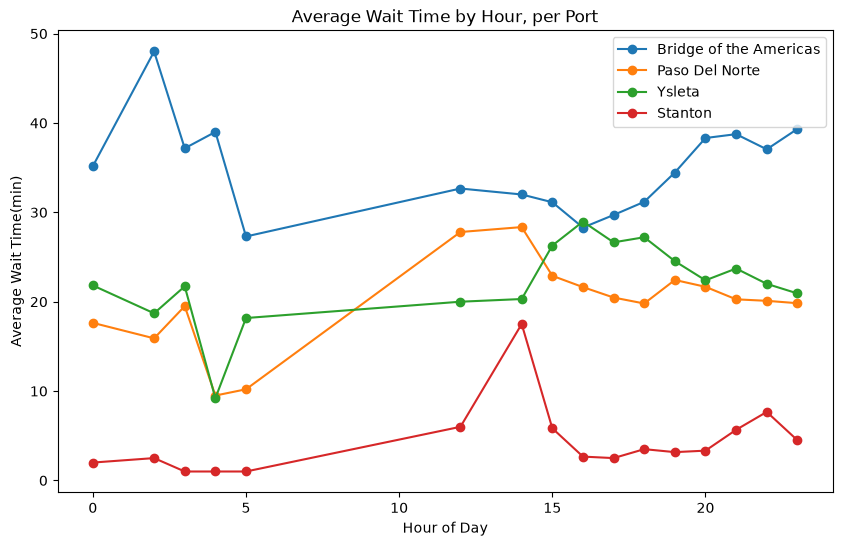

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

for port in reported.port_name.unique():
    port_data = avg_by_hour_report[port]
    ax.plot(port_data.index, port_data.values, marker='o', label=port)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Wait Time(min)")
ax.set_title("Average Wait Time by Hour, per Port")
ax.legend()
plt.show()

In [38]:
counts = reported.groupby(["port_name", "hour"]).wait_minutes.count().unstack()
counts

hour,0,2,3,4,5,12,14,15,16,17,18,19,20,21,22,23
port_name,,,,,,,,,,,,,,,,
Bridge of the Americas,21,9,18,8,13,3,13,26,30,30,31,27,25,23,22,21
Paso Del Norte,35,15,28,10,23,5,20,35,34,34,34,34,34,34,34,35
Stanton,7,3,6,3,6,1,4,7,7,7,7,7,7,7,7,7
Ysleta,31,13,26,13,28,5,20,33,33,33,33,33,33,31,31,31


**Data quality note:** hours 2-5 and 12 have notably fewer readings across all ports
(likely due to an early scraper bug, since fixed) and should be treated as lower-confidence.
Stanton has consistently fewer readings than the other three ports throughout the week.

In [9]:
avg_time = reported.groupby("port_name").wait_minutes.mean()
avg_time

port_name
Bridge of the Americas    33.985294
Paso Del Norte            20.313984
Stanton                    4.363636
Ysleta                    23.252078
Name: wait_minutes, dtype: float64

Reported by Day

In [10]:
avg_by_day_report = reported.groupby(["port_name", "day_of_week"]).wait_minutes.mean()
avg_by_day_report

port_name               day_of_week
Bridge of the Americas  Friday         30.000000
                        Monday         35.666667
                        Saturday       43.333333
                        Sunday         34.971429
                        Thursday       30.100000
                        Tuesday        37.021739
                        Wednesday      34.714286
Paso Del Norte          Friday         14.546875
                        Monday         24.423729
                        Saturday       17.300000
                        Sunday         29.333333
                        Thursday       14.140625
                        Tuesday        22.500000
                        Wednesday      20.275362
Stanton                 Friday          6.769231
                        Monday          4.500000
                        Saturday        3.500000
                        Sunday          3.222222
                        Thursday        2.153846
                        Tuesday  

Day Chart

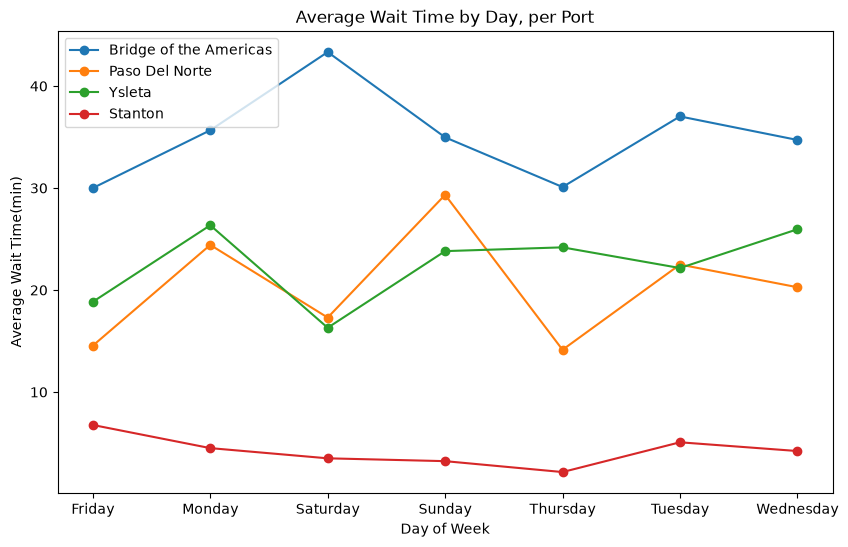

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

for port in reported.port_name.unique():
    port_data = avg_by_day_report[port]
    ax.plot(port_data.index, port_data.values, marker='o', label=port)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Wait Time(min)")
ax.set_title("Average Wait Time by Day, per Port")
ax.legend()
plt.show()

How many Sentri/Ready lanes are open while the General Lane is closed?

In [6]:
lanes = df[(df.category == 'Passenger Vehicles') & (df.lane_type.isin(['Sentri', 'General', 'Ready']))]
lanes

,port_name,category,lane_type,status,wait_minutes,timestamp,hour,day_of_week
2,Bridge of the Americas,Passenger Vehicles,General,reported,50.0,2026-08-09 15:26:14.176934,15,Sunday
3,Bridge of the Americas,Passenger Vehicles,Sentri,not applicable,NaN,2026-08-09 15:26:14.176934,15,Sunday
4,Bridge of the Americas,Passenger Vehicles,Ready,reported,45.0,2026-08-09 15:26:14.176934,15,Sunday
9,Paso Del Norte,Passenger Vehicles,General,reported,54.0,2026-08-09 15:26:14.176934,15,Sunday
10,Paso Del Norte,Passenger Vehicles,Sentri,reported,5.0,2026-08-09 15:26:14.176934,15,Sunday
...,...,...,...,...,...,...,...,...
2593,Ysleta,Passenger Vehicles,Sentri,reported,15.0,2026-08-16 04:23:54.417784,4,Sunday
2594,Ysleta,Passenger Vehicles,Ready,reported,70.0,2026-08-16 04:23:54.417784,4,Sunday
2599,Stanton,Passenger Vehicles,General,closed,NaN,2026-08-16 04:23:54.417784,4,Sunday
2600,Stanton,Passenger Vehicles,Sentri,reported,1.0,2026-08-16 04:23:54.417784,4,Sunday


In [7]:
lanes_wide = lanes.pivot(index=['port_name', 'timestamp'], columns='lane_type', values='status')
lanes_wide

lane_type                                           General     Ready  \
port_name              timestamp                                        
Bridge of the Americas 2026-08-09 15:26:14.176934  reported  reported   
                       2026-08-09 16:19:22.336910  reported  reported   
                       2026-08-09 17:19:54.172436  reported  reported   
                       2026-08-09 18:21:26.525818  reported  reported   
                       2026-08-09 19:23:16.904361  reported  reported   
...                                                     ...       ...   
Ysleta                 2026-08-15 23:09:41.198493    closed  reported   
                       2026-08-16 00:31:50.179399    closed  reported   
                       2026-08-16 02:14:14.694061    closed  reported   
                       2026-08-16 03:37:25.119384    closed  reported   
                       2026-08-16 04:23:54.417784    closed  reported   

lane_type                                                  Sentri  
port_name              timestamp                                   
Bridge of the Americas 2026-08-09 15:26:14.176934  not applicable  
                       2026-08-09 16:19:22.336910  not applicable  
                       2026-08-09 17:19:54.172436  not applicable  
                       2026-08-09 18:21:26.525818  not applicable  
                       2026-08-09 19:23:16.904361  not applicable  
...                                                           ...  
Ysleta                 2026-08-15 23:09:41.198493        reported  
                       2026-08-16 00:31:50.179399        reported  
                       2026-08-16 02:14:14.694061        reported  
                       2026-08-16 03:37:25.119384        reported  
                       2026-08-16 04:23:54.417784        reported  

[372 rows x 3 columns]

In [8]:
compare_lanes = lanes_wide[~lanes_wide['General'].str.contains('reported')] 
compare_lanes = compare_lanes[compare_lanes['Sentri'].str.contains('reported') | compare_lanes['Ready'].str.contains('reported')]
compare_lanes

lane_type                            General           Ready    Sentri
port_name timestamp                                                   
Stanton   2026-08-09 15:26:14.176934  closed  not applicable  reported
          2026-08-09 16:19:22.336910  closed  not applicable  reported
          2026-08-09 17:19:54.172436  closed  not applicable  reported
          2026-08-09 18:21:26.525818  closed  not applicable  reported
          2026-08-09 19:23:16.904361  closed  not applicable  reported
...                                      ...             ...       ...
Ysleta    2026-08-15 23:09:41.198493  closed        reported  reported
          2026-08-16 00:31:50.179399  closed        reported  reported
          2026-08-16 02:14:14.694061  closed        reported  reported
          2026-08-16 03:37:25.119384  closed        reported  reported
          2026-08-16 04:23:54.417784  closed        reported  reported

[186 rows x 3 columns]

In [60]:
pct = len(compare_lanes) / len(lanes_wide) * 100
pct

50.0

In [61]:
compare_lanes.groupby('port_name').size()

port_name
Stanton    93
Ysleta     93
dtype: int64

In [66]:
compare_lanes.groupby("port_name").size()

port_name
Stanton    93
Ysleta     93
dtype: int64

In [10]:
closure_rate = lanes_wide.reset_index().groupby('port_name').apply(
    lambda g: g.General =="closed").mean() * 100
closure_rate

np.float64(50.53763440860215)